In [1]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


### Loading and Inspecting Corpus Scifact Dataset

In [2]:
#loading corpus
corpus_data = load_dataset('allenai/scifact', 'corpus')
corpus_data

DatasetDict({
    train: Dataset({
        features: ['doc_id', 'title', 'abstract', 'structured'],
        num_rows: 5183
    })
})

In [3]:
#selecting traning dataset to perform data preprocessing and EDA
train = corpus_data['train']
corpus_df = pd.DataFrame(train)
corpus_df

,doc_id,title,abstract,structured
0,4983,Microstructural development of human newborn c...,[Alterations of the architecture of cerebral w...,False
1,5836,Induction of myelodysplasia by myeloid-derived...,[Myelodysplastic syndromes (MDS) are age-depen...,False
2,7912,"BC1 RNA, the transcript from a master gene for...",[ID elements are short interspersed elements (...,False
3,18670,The DNA Methylome of Human Peripheral Blood Mo...,[DNA methylation plays an important role in bi...,False
4,19238,The human myelin basic protein gene is include...,[Two human Golli (for gene expressed in the ol...,False
...,...,...,...,...
5178,195689316,Body-mass index and cause-specific mortality i...,[BACKGROUND The main associations of body-mass...,True
5179,195689757,Targeting metabolic remodeling in glioblastoma...,[A key aberrant biological difference between ...,False
5180,196664003,Signaling architectures that transmit unidirec...,[A signaling pathway transmits information fro...,False
5181,198133135,"Association between pre-diabetes, type 2 diabe...",[AIMS Trabecular bone score (TBS) is a surroga...,True


In [4]:
corpus_df.shape

(5183, 4)

In [5]:
corpus_df.columns.tolist()

['doc_id', 'title', 'abstract', 'structured']

In [6]:
#printing clean first entry to understand the structure of the data
doc_01 = corpus_df.iloc[0]
print(f"Document ID: {doc_01['doc_id']}")
print(f"\nTitle: {doc_01['title']}")
print(f"\nAbstract:{doc_01['abstract']}")
print(f"\nStructured:{doc_01['structured']}")

Document ID: 4983

Title: Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.

Abstract:['Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities.', 'A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7).', 'To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term.', 'In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms.', 'In the posterior limb of the internal

In [7]:
len(corpus_df)

5183

In [8]:
corpus_df['doc_id'].nunique()

5183

In [9]:
corpus_df['doc_id'].head(15)

0      4983
1      5836
2      7912
3     18670
4     19238
5     33370
6     36474
7     54440
8     70115
9     70490
10    72159
11    79447
12    87758
13    92308
14    92499
Name: doc_id, dtype: int64

In [10]:
corpus_df.isnull().sum()

doc_id        0
title         0
abstract      0
structured    0
dtype: int64

In [11]:
corpus_df['doc_id'].duplicated().sum()

0

In [12]:
corpus_df['title'].duplicated().sum()

2

In [13]:
corpus_df[corpus_df['title'].duplicated(keep=False)].sort_values('title')

,doc_id,title,abstract,structured
163,885056,Summary,"[Steroid receptor RNA activator (SRA), the onl...",False
2201,13492264,Summary,[Glomerular basement membrane (GBM) and podoca...,False
2337,14178995,Summary,[The genetic diseases Hutchinson-Gilford proge...,False


In [14]:
type(corpus_df['abstract'])

pandas.core.series.Series

In [15]:
#understanding the expected length of corpus in words and characters
corpus_df['string_abstract'] = corpus_df['abstract'].apply(
    lambda x: ''.join(x) if isinstance(x,list) else(""if x is none else str(x))
)

In [16]:
corpus_df['word_count'] = corpus_df['string_abstract'].apply(lambda text: len(text.split())) 
corpus_df['char_count'] = corpus_df['string_abstract'].apply(len)

In [18]:
#sample for ccorpus_df
doc_01 = corpus_df.iloc[0]
print(f"Document ID: {doc_01['doc_id']}")
print(f"\nTitle: {doc_01['title']}")
print(f"\nAbstract:{doc_01['abstract']}")
print(f"\nStructured:{doc_01['structured']}")
print(f"\nString Abstract:{doc_01['string_abstract']}")
print(f"\nWord Count:{doc_01['word_count']}")
print(f"\nCharacter Count:{doc_01['char_count']}")

Document ID: 4983

Title: Microstructural development of human newborn cerebral white matter assessed in vivo by diffusion tensor magnetic resonance imaging.

Abstract:['Alterations of the architecture of cerebral white matter in the developing human brain can affect cortical development and result in functional disabilities.', 'A line scan diffusion-weighted magnetic resonance imaging (MRI) sequence with diffusion tensor analysis was applied to measure the apparent diffusion coefficient, to calculate relative anisotropy, and to delineate three-dimensional fiber architecture in cerebral white matter in preterm (n = 17) and full-term infants (n = 7).', 'To assess effects of prematurity on cerebral white matter development, early gestation preterm infants (n = 10) were studied a second time at term.', 'In the central white matter the mean apparent diffusion coefficient at 28 wk was high, 1.8 microm2/ms, and decreased toward term to 1.2 microm2/ms.', 'In the posterior limb of the internal

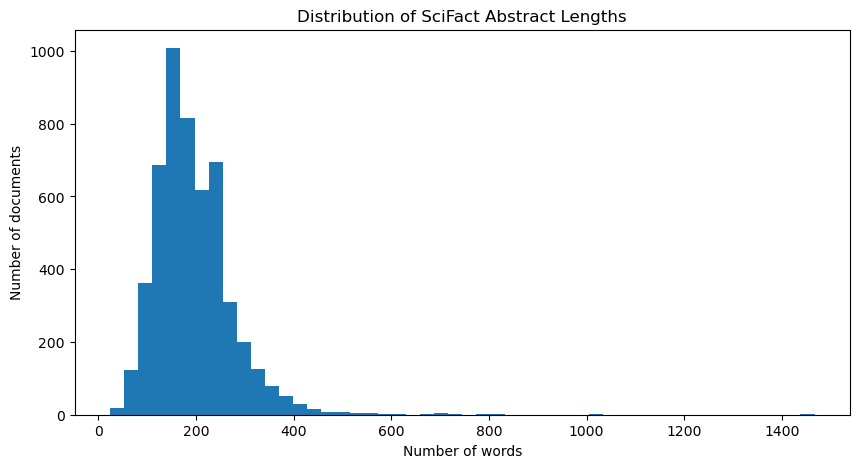

In [19]:
#Graph to understand distribution of word count in corpus dataset 
plt.figure(figsize=(10, 5))

plt.hist(
    corpus_df["word_count"],
    bins=50
)

plt.xlabel("Number of words")
plt.ylabel("Number of documents")
plt.title("Distribution of SciFact Abstract Lengths")

plt.show()

In [20]:
#Entries with least word count
corpus_df[['title','string_abstract', 'word_count']].sort_values(by ='word_count').head(20)

,title,string_abstract,word_count
4370,On the origins of ultra-fine anaphase bridges.,"Comment on: Chan KL, Palmai-Pallag T, Ying S, ...",24
5076,The Endothelium: Modulator of Cardiovascular F...,Introduction.Methods To Study Endothelium-Depe...,27
5097,The Bitterest Pills: The Troubling Story of An...,© Joanna Moncrieff 2013.All rights reserved.A ...,34
4124,New developments in the epidemiology of cancer...,There have been numerous epidemiologic investi...,40
5088,The Women's Interagency HIV Study,The Women's Interagency HIV Study comprises th...,42
5099,Chromosome numbers in certain Indian species o...,Chromosome numbers from meiotic studies have b...,43
5110,Reproductive physiology of marsupials,Preface 1.Historical introduction 2.Breeding b...,45
4623,The aurora B kinase promotes inner and outer k...,The kinetochore is the macromolecular protein ...,45
5106,Innate immunity to a facultative intracellular...,The murine response to Listeria monocytogenes ...,45
1833,Model-based Geostatistics,Geostatistics is concerned with estimation and...,47


In [21]:
#entries with most word count
corpus_df[['title','string_abstract', 'word_count']].sort_values(by ='word_count',ascending=False).head(20)

,title,string_abstract,word_count
1834,Placebo-Controlled Trials and Active-Control T...,Placebo-controlled trials are used extensively...,1467
3866,Screening for Lung Cancer: U.S. Preventive Ser...,The U.S. Preventive Services Task Force (USPST...,1439
4011,Open Access Increases Citation Rate,PLoS Biology publishes today a research articl...,1029
2510,Keeping your senescent cells under control,Cellular senescence is a stable form of cell-c...,1021
969,Pharmacological interventions for smoking cess...,BACKGROUND Smoking is the leading preventable ...,806
1775,Developing primary palliative care.,Although 65% of people with cancer want to die...,775
1228,Ribosome biogenesis: Achilles heel of cancer?,It is long been known that cancer and non-canc...,739
4551,Malaria eradication back on the table.,"After a lapse of almost 40 years, malaria erad...",711
5118,The Self-Incompatibility Genes of Brassica: Ex...,INTRODUCTION . . . . . . . . . . . . . . . . ....,700
4408,Ibuprofen for the treatment of patent ductus a...,BACKGROUND Indomethacin is used as standard th...,694


In [22]:
#summary of word count using statistics
corpus_df["title_word_count"] = (
    corpus_df["title"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

corpus_df["title_word_count"].describe()

count    5183.000000
mean       12.817094
std         4.733675
min         1.000000
25%        10.000000
50%        12.000000
75%        16.000000
max        40.000000
Name: title_word_count, dtype: float64

In [27]:
#EDA of structured column
type(corpus_df['structured'])

pandas.core.series.Series

In [28]:
corpus_df['structured']

0       False
1       False
2       False
3       False
4       False
        ...  
5178     True
5179    False
5180    False
5181     True
5182    False
Name: structured, Length: 5183, dtype: bool

In [29]:
type(corpus_df.iloc[0]['structured'])

numpy.bool_

In [30]:
corpus_df.iloc[0]['structured']

False

In [31]:
corpus_df["structured"].map(type).value_counts()

structured
<class 'bool'>    5183
Name: count, dtype: int64

Text(0.5, 1.0, 'Comparison of True vs False in Structured Column')

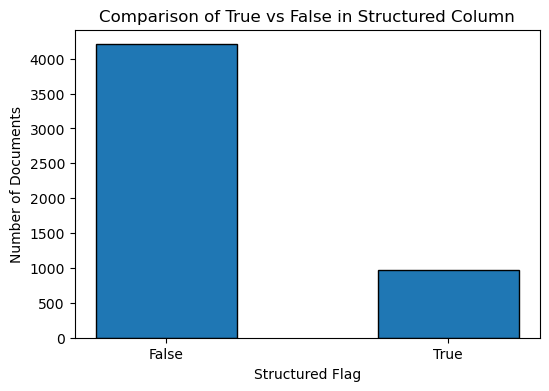

In [32]:
#Graph to see distribution of True and False
counts = corpus_df["structured"].value_counts(dropna=False)

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values, edgecolor="black", width=0.5)

plt.xlabel("Structured Flag")
plt.ylabel("Number of Documents")
plt.title("Comparison of True vs False in Structured Column")

### Loading and Inspecting Claims Scifact Dataset

In [33]:
claims_data = load_dataset('allenai/scifact','claims')
claims_data['train']

Dataset({
    features: ['id', 'claim', 'evidence_doc_id', 'evidence_label', 'evidence_sentences', 'cited_doc_ids'],
    num_rows: 1261
})

In [34]:
train = claims_data['train']
claims_df = pd.DataFrame(train)
claims_df

,id,claim,evidence_doc_id,evidence_label,evidence_sentences,cited_doc_ids
0,0,0-dimensional biomaterials lack inductive prop...,,,[],[31715818]
1,2,1 in 5 million in UK have abnormal PrP positiv...,13734012,CONTRADICT,[4],[13734012]
2,4,1-1% of colorectal cancer patients are diagnos...,,,[],[22942787]
3,6,10% of sudden infant death syndrome (SIDS) dea...,,,[],[2613775]
4,9,32% of liver transplantation programs required...,44265107,SUPPORT,[15],[44265107]
...,...,...,...,...,...,...
1256,1404,siRNA knockdown of A20 slows tumor progression...,38355793,SUPPORT,[8],"[33370, 38355793]"
1257,1404,siRNA knockdown of A20 slows tumor progression...,38355793,SUPPORT,[9],"[33370, 38355793]"
1258,1405,taa1 tar1 tar2 triple mutants in Arabidopsis d...,,,[],[10504681]
1259,1406,β-sheet opening occurs during pleurotolysin po...,2617858,SUPPORT,[4],[2617858]


In [35]:
claims_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1261 entries, 0 to 1260
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  1261 non-null   int64 
 1   claim               1261 non-null   object
 2   evidence_doc_id     1261 non-null   object
 3   evidence_label      1261 non-null   object
 4   evidence_sentences  1261 non-null   object
 5   cited_doc_ids       1261 non-null   object
dtypes: int64(1), object(5)
memory usage: 59.2+ KB


In [36]:
 claims_df.iloc[0]

id                                                                    0
claim                 0-dimensional biomaterials lack inductive prop...
evidence_doc_id                                                        
evidence_label                                                         
evidence_sentences                                                   []
cited_doc_ids                                                [31715818]
Name: 0, dtype: object

In [37]:
 claims_df.iloc[5]['claim']

'4-PBA treatment decreases endoplasmic reticulum stress in response to general endoplasmic reticulum stress markers.'

In [38]:
pd.set_option("display.max_colwidth", 300)

claims_df.head(10)

,id,claim,evidence_doc_id,evidence_label,evidence_sentences,cited_doc_ids
0,0,0-dimensional biomaterials lack inductive properties.,,,[],[31715818]
1,2,1 in 5 million in UK have abnormal PrP positivity.,13734012,CONTRADICT,[4],[13734012]
2,4,1-1% of colorectal cancer patients are diagnosed with regional or distant metastases.,,,[],[22942787]
3,6,10% of sudden infant death syndrome (SIDS) deaths happen in newborns aged less than 6 months.,,,[],[2613775]
4,9,32% of liver transplantation programs required patients to discontinue methadone treatment in 2001.,44265107,SUPPORT,[15],[44265107]
5,10,4-PBA treatment decreases endoplasmic reticulum stress in response to general endoplasmic reticulum stress markers.,,,[],[32587939]
6,11,4-PBA treatment raises endoplasmic reticulum stress in response to general endoplasmic reticulum stress markers.,,,[],[32587939]
7,12,40mg/day dosage of folic acid and 2mg/day dosage of vitamin B12 does not affect chronic kidney disease (CKD) progression.,33409100,SUPPORT,[8],[33409100]
8,12,40mg/day dosage of folic acid and 2mg/day dosage of vitamin B12 does not affect chronic kidney disease (CKD) progression.,33409100,SUPPORT,[12],[33409100]
9,14,5'-nucleotidase metabolizes 6MP.,,,[],[641786]


In [39]:
#Checking of IDs are unique or not 
len(claims_df)

1261

In [40]:
claims_df['id'].nunique()

809

In [42]:
claims_df['id'].duplicated().sum()

452

In [43]:
claims_df['id'].duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1256     True
1257     True
1258    False
1259    False
1260    False
Name: id, Length: 1261, dtype: bool

In [46]:
#IDs are not unique so we are counting on number of iteration an ID have used
claims_df["id"].value_counts()

id
378     11
108      9
1181     9
1005     8
1004     8
        ..
559      1
562      1
563      1
564      1
1407     1
Name: count, Length: 809, dtype: int64

In [48]:
#seperating unique IDs and IDs with multiple occurrence
claim_count = claims_df['id'].value_counts()

multi_evidence = claim_count[claim_count > 1]
single_evidence = claim_count[claim_count == 1]

print(len(multi_evidence))
print(len(single_evidence))

255
554


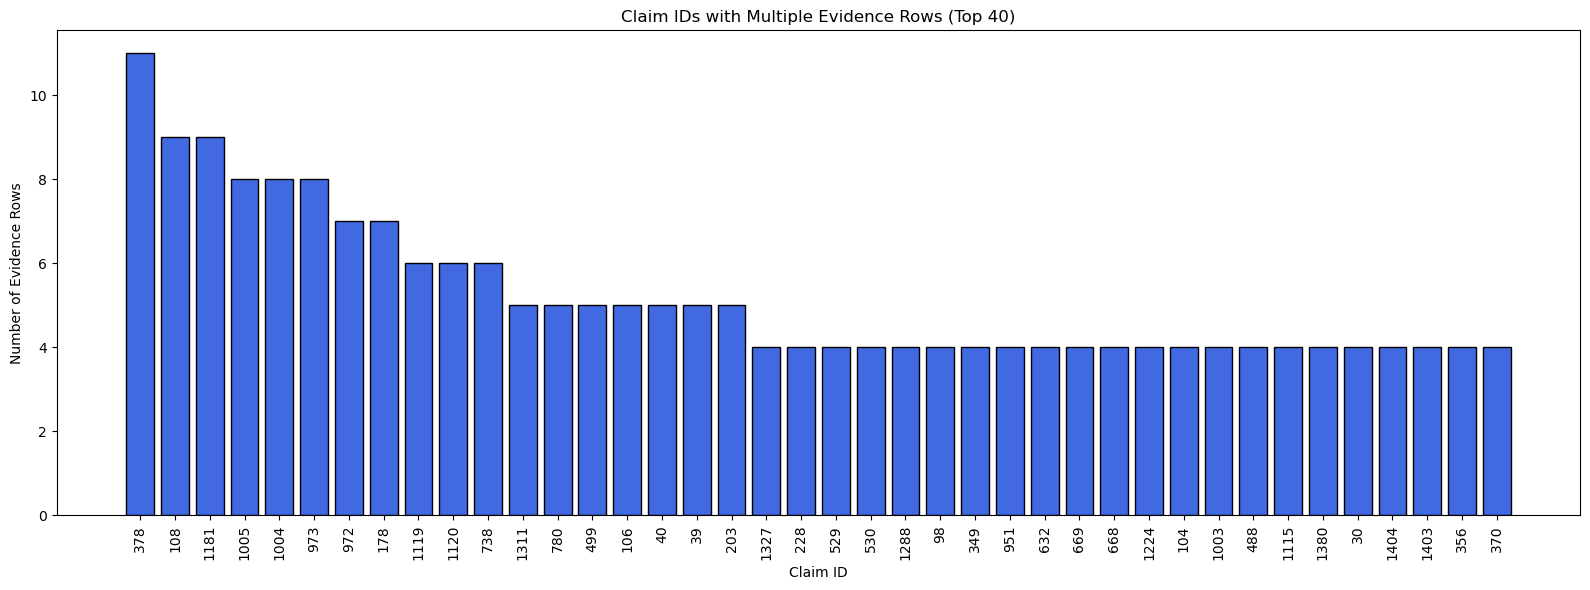

In [49]:
#Visual Representation
top_multi = multi_evidence.head(40)

plt.figure(figsize=(16, 6))
plt.bar(top_multi.index.astype(str), top_multi.values, color="royalblue", edgecolor="black")

plt.xlabel("Claim ID")
plt.ylabel("Number of Evidence Rows")
plt.title("Claim IDs with Multiple Evidence Rows (Top 40)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [50]:
#Looking for reason behind repeated occurence of an ID
sample = claims_df[claims_df["id"] == 378]
sample

,id,claim,evidence_doc_id,evidence_label,evidence_sentences,cited_doc_ids
350,378,Energy balance requires hypothalamic glutamate neurotransmission.,45154987,SUPPORT,[5],"[45154987, 10534299, 11886686, 25007443, 17150648]"
351,378,Energy balance requires hypothalamic glutamate neurotransmission.,45154987,SUPPORT,[7],"[45154987, 10534299, 11886686, 25007443, 17150648]"
352,378,Energy balance requires hypothalamic glutamate neurotransmission.,45154987,SUPPORT,[8],"[45154987, 10534299, 11886686, 25007443, 17150648]"
353,378,Energy balance requires hypothalamic glutamate neurotransmission.,10534299,SUPPORT,[3],"[45154987, 10534299, 11886686, 25007443, 17150648]"
354,378,Energy balance requires hypothalamic glutamate neurotransmission.,10534299,SUPPORT,[4],"[45154987, 10534299, 11886686, 25007443, 17150648]"
355,378,Energy balance requires hypothalamic glutamate neurotransmission.,10534299,SUPPORT,[5],"[45154987, 10534299, 11886686, 25007443, 17150648]"
356,378,Energy balance requires hypothalamic glutamate neurotransmission.,10534299,SUPPORT,[6],"[45154987, 10534299, 11886686, 25007443, 17150648]"
357,378,Energy balance requires hypothalamic glutamate neurotransmission.,11886686,SUPPORT,[7],"[45154987, 10534299, 11886686, 25007443, 17150648]"
358,378,Energy balance requires hypothalamic glutamate neurotransmission.,17150648,SUPPORT,[2],"[45154987, 10534299, 11886686, 25007443, 17150648]"
359,378,Energy balance requires hypothalamic glutamate neurotransmission.,17150648,SUPPORT,[3],"[45154987, 10534299, 11886686, 25007443, 17150648]"


In [51]:
#EDA for Evidence label
claims_df['evidence_label'].value_counts()

evidence_label
SUPPORT       616
CONTRADICT    341
              304
Name: count, dtype: int64

In [52]:
#Filling Nulls 
clean_evidence_label = claims_df['evidence_label'].replace('',None).fillna('NO EVIDENCE')

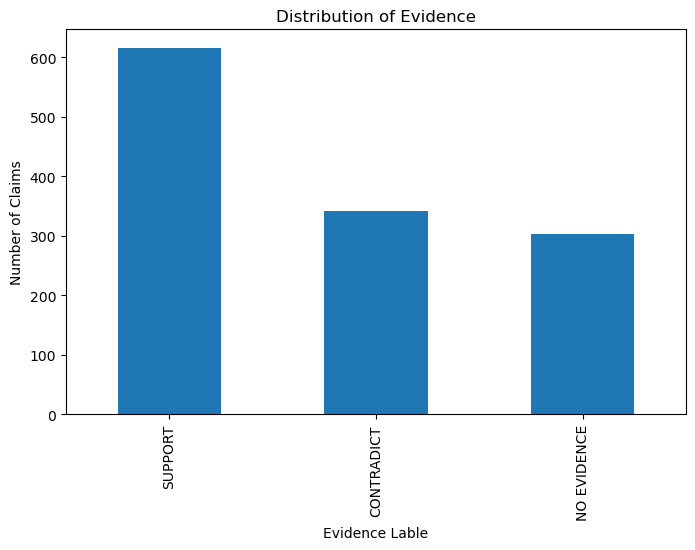

In [54]:
clean_evidence_label.value_counts().plot(
    kind = 'bar',
    figsize = (8,5)
)
plt.xlabel('Evidence Lable')
plt.ylabel('Number of Claims')
plt.title('Distribution of Evidence')

plt.xticks(rotation = 90)
plt.show()

In [55]:
#percentage distribution
label_percentages = clean_evidence_label.value_counts(normalize=True, dropna=False).mul(100).round(2)
label_counts = clean_evidence_label.value_counts()
label_summary = pd.DataFrame({
    "Count": label_counts,
    "Percentage": label_percentages
})

label_summary

,Count,Percentage
evidence_label,,
SUPPORT,616,48.85
CONTRADICT,341,27.04
NO EVIDENCE,304,24.11


In [49]:
claims_df['evidence_doc_id'].nunique()

366

In [51]:
claims_df['evidence_doc_id'].value_counts().head(20)

evidence_doc_id
            304
13497630     14
2734421      12
9315213       9
18174210      8
33370         8
16472469      8
7552215       8
25148216      8
12258338      8
6540064       8
1550937       8
4200695       8
17077004      8
14803797      7
24341590      7
3355397       7
16120395      6
14606752      6
3952288       6
Name: count, dtype: int64

### Connecting Corpus and Claims

In [56]:
#connecting coupus with claims
corpus_doc_ids = set(corpus_df["doc_id"])

claims_df["evidence_doc_in_corpus"] = (
    claims_df["evidence_doc_id"].isin(corpus_doc_ids)
)

claims_df["evidence_doc_in_corpus"].value_counts()

evidence_doc_in_corpus
False    1261
Name: count, dtype: int64

In [57]:
#Every entry return to false because of different datatype that we noticed and changes and reconnected again in following cells

In [58]:
print(type(corpus_df["doc_id"].dropna().iloc[0]))
print(type(claims_df["evidence_doc_id"].dropna().iloc[0]))

<class 'numpy.int64'>
<class 'str'>


In [59]:
corpus_df['doc_id_str'] = (corpus_df['doc_id'].astype(str).str.strip())
claims_df['evidence_doc_id_str'] = (claims_df['evidence_doc_id'].astype(str).str.strip())

In [60]:
corpus_doc_ids = set(corpus_df['doc_id_str'])
claims_df['evidence_doc_in_corpus'] = (claims_df['evidence_doc_id_str'].isin(corpus_doc_ids))
claims_df['evidence_doc_in_corpus'].value_counts()

evidence_doc_in_corpus
True     957
False    304
Name: count, dtype: int64

In [62]:
#calculating Matching rate to see what percentage of data is connected from both datasets
match_rate = (
    claims_df["evidence_doc_in_corpus"].mean() * 100
)

print(
    f"Evidence documents found in corpus: {match_rate:.2f}%"
)

Evidence documents found in corpus: 75.89%


In [66]:
#100-75.89 = 24.11, 24.11 is unmatched data lets investigate that lot

unmatched_claims = claims_df[~claims_df["evidence_doc_in_corpus"]]

print("Number of unmatched claims:", len(unmatched_claims))
unmatched_claims.head(10)

Number of unmatched claims: 304


,id,claim,evidence_doc_id,evidence_label,evidence_sentences,cited_doc_ids,evidence_doc_in_corpus,evidence_doc_id_str
0,0,0-dimensional biomaterials lack inductive properties.,,,[],[31715818],False,
2,4,1-1% of colorectal cancer patients are diagnosed with regional or distant metastases.,,,[],[22942787],False,
3,6,10% of sudden infant death syndrome (SIDS) deaths happen in newborns aged less than 6 months.,,,[],[2613775],False,
5,10,4-PBA treatment decreases endoplasmic reticulum stress in response to general endoplasmic reticulum stress markers.,,,[],[32587939],False,
6,11,4-PBA treatment raises endoplasmic reticulum stress in response to general endoplasmic reticulum stress markers.,,,[],[32587939],False,
9,14,5'-nucleotidase metabolizes 6MP.,,,[],[641786],False,
10,15,50% of patients exposed to radiation have activated markers of mesenchymal stem cells.,,,[],[22080671],False,
11,17,53% of perinatal mortality is due to low birth weight.,,,[],[1606628],False,
12,18,61% of colorectal cancer patients are diagnosed with regional or distant metastases.,,,[],[22942787],False,
13,19,7-day-old adult Caenorhabditis elegans exhibit approximately 5% of the learning capacity seen in 1-day old adults.,,,[],[3202143],False,


In [79]:
#entries with no evidence doc id failed to connect with corpus
#lets confirm our observations

In [80]:
#creating status coloum 
claims_df["evidence_status"] = np.where(
    claims_df["evidence_doc_id"].isna() | (claims_df["evidence_doc_id"].astype(str).str.strip() == ""),
    "No evidence document",
    np.where(claims_df["evidence_doc_in_corpus"], "Evidence document found", "Evidence document not found")
)
claims_df["evidence_status"].value_counts()

evidence_status
Evidence document found    957
No evidence document       304
Name: count, dtype: int64

In [81]:
#hence proved number of false and number of null matched 

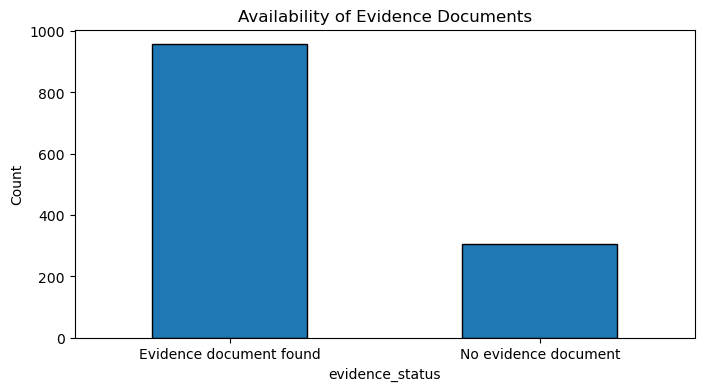

In [82]:
#bar chart
claims_df["evidence_status"].value_counts().plot(kind="bar", figsize=(8, 4), rot=0, edgecolor="black")
plt.title("Availability of Evidence Documents")
plt.ylabel("Count")
plt.show()

In [83]:
summary = claims_df["evidence_status"].value_counts().to_frame(name="Count")
summary["Percentage"] = (claims_df["evidence_status"].value_counts(normalize=True) * 100).round(2)
summary

,Count,Percentage
evidence_status,,
Evidence document found,957,75.89
No evidence document,304,24.11
